In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from matplotlib.lines import Line2D

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [ ]:
try:
    from google.colab import files as colab_files
    uploaded = colab_files.upload()
    if uploaded:
        csv_path = list(uploaded.keys())[0]
    else:
        csv_path = 'all_5_crops_combined.csv'
except Exception:
    csv_path = 'all_5_crops_combined.csv'

raw = pd.read_csv(csv_path)

def _norm(colname):
    return colname.strip().lower().replace(' ', '_')

rename_map = {}
for c in raw.columns:
    n = _norm(c)
    if n in ('farm_id', 'farm', 'farmid'):
        rename_map[c] = 'Farm'
    elif n in ('crop_label', 'crop', 'croplabel'):
        rename_map[c] = 'Crop'
    elif n == 'date':
        rename_map[c] = 'Date'
    elif n == 'ndvi':
        rename_map[c] = 'NDVI'
    elif n in ('ground_truth_date', 'ground_truth_month', 'groundtruth'):
        rename_map[c] = 'Ground_Truth'

raw = raw.rename(columns=rename_map)

raw['Date'] = pd.to_datetime(raw['Date'], format='%d-%m-%Y')

raw = raw.groupby(['Farm', 'Crop', 'Date'], as_index=False)['NDVI'].mean()

raw = raw[raw['NDVI'] >= 0].reset_index(drop=True)

df = raw.sort_values(['Crop', 'Farm', 'Date']).reset_index(drop=True)
ndvi_df = df[['Crop', 'Farm', 'Date', 'NDVI']].copy()

print('Loaded:', df.shape)
print('Crops:', df['Crop'].unique())
print('Total farms:', df['Farm'].nunique())
print('Date range:', df['Date'].min().date(), '→', df['Date'].max().date())
print('NDVI range:', round(df['NDVI'].min(), 3), '→', round(df['NDVI'].max(), 3))
print()
print(df.groupby('Crop')['Farm'].nunique().rename('n_farms'))

Saving all_5_crops_combined.csv to all_5_crops_combined.csv
Loaded: (7748, 4)
Crops: ['Cotton' 'Onion' 'Paddy' 'Sugarcane' 'Tomato']
Total farms: 198
Date range: 2021-01-03 → 2026-04-30
NDVI range: 0.001 → 0.977

Crop
Cotton       23
Onion        50
Paddy        25
Sugarcane    50
Tomato       50
Name: n_farms, dtype: int64


In [ ]:
CROP_CONFIG = {
    'Gram':        {'smooth': 4, 'max_cycles': 1, 'search_months': 4, 'use_prominence': False, 'prominence': None},
    'Lentil':      {'smooth': 4, 'max_cycles': 1, 'search_months': 4, 'use_prominence': False, 'prominence': None},
    'Maize':       {'smooth': 4, 'max_cycles': 1, 'search_months': 4, 'use_prominence': False, 'prominence': None},
    'Mustard':     {'smooth': 4, 'max_cycles': 1, 'search_months': 4, 'use_prominence': False, 'prominence': None},
    'Potato':      {'smooth': 4, 'max_cycles': 1, 'search_months': 4, 'use_prominence': False, 'prominence': None},
    'Rice':        {'smooth': 4, 'max_cycles': 1, 'search_months': 5, 'use_prominence': False, 'prominence': None},
    'Wheat':       {'smooth': 4, 'max_cycles': 1, 'search_months': 4, 'use_prominence': False, 'prominence': None},
    'Sugarcane':   {'smooth': 6, 'max_cycles': 1, 'search_months': 8, 'use_prominence': True,  'prominence': 0.08},
    'Banana':      {'smooth': 6, 'max_cycles': 1, 'search_months': 7, 'use_prominence': True,  'prominence': 0.06},
    'Grapes':      {'smooth': 3, 'max_cycles': 2, 'search_months': 3, 'use_prominence': True,  'prominence': 0.10},
    'Onion':       {'smooth': 2, 'max_cycles': 1, 'search_months': 3, 'use_prominence': False, 'prominence': None},
    'Tomato':      {'smooth': 3, 'max_cycles': 3, 'search_months': 2, 'use_prominence': False, 'prominence': None},
    'Paddy':       {'smooth': 3, 'max_cycles': 2, 'search_months': 3, 'use_prominence': True,  'prominence': 0.15},
    'Soybean':     {'smooth': 4, 'max_cycles': 1, 'search_months': 4, 'use_prominence': False, 'prominence': None},
    'Cotton':      {'smooth': 2, 'max_cycles': 2, 'search_months': 4, 'use_prominence': True,  'prominence': 0.07},
    'Jowar':       {'smooth': 4, 'max_cycles': 2, 'search_months': 4, 'use_prominence': False, 'prominence': None},
    'Bajra':       {'smooth': 3, 'max_cycles': 1, 'search_months': 3, 'use_prominence': False, 'prominence': None},
    'Tur':         {'smooth': 5, 'max_cycles': 1, 'search_months': 6, 'use_prominence': False, 'prominence': None},
    'Turmeric':    {'smooth': 6, 'max_cycles': 1, 'search_months': 8, 'use_prominence': True,  'prominence': 0.06},
    'Pomegranate': {'smooth': 6, 'max_cycles': 2, 'search_months': 4, 'use_prominence': True,  'prominence': 0.07},
    'Safflower':   {'smooth': 3, 'max_cycles': 2, 'search_months': 3, 'use_prominence': True,  'prominence': 0.08},
    'Cabbage':     {'smooth': 3, 'max_cycles': 3, 'search_months': 2, 'use_prominence': False, 'prominence': None}
}

DEFAULT_CFG = {'smooth': 4, 'max_cycles': 1, 'search_months': 4, 'use_prominence': False, 'prominence': None}

print('Total crops configured:', len(CROP_CONFIG))
print([c for c in CROP_CONFIG if c in df['Crop'].unique()], '← active for this dataset')

Total crops configured: 22
['Sugarcane', 'Onion', 'Tomato', 'Paddy', 'Cotton'] ← active for this dataset


## 3. Detection Functions

In [ ]:
def split_into_years(dates):
    start = dates.min()
    end   = dates.max()
    segments = []
    seg_start = start
    while seg_start <= end:
        seg_end = seg_start + pd.DateOffset(years=1)
        segments.append((seg_start, seg_end))
        seg_start = seg_end
    return segments


def detect_cycles(dates, ndvi, cfg):
    s = pd.Series(ndvi).rolling(cfg['smooth'], center=True, min_periods=1).mean().values
    max_cycles = cfg['max_cycles']
    min_dist = max(3, len(s) // (max_cycles * 3))

    if cfg['use_prominence']:
        peaks, _ = find_peaks(s, prominence=cfg['prominence'], distance=min_dist)
    else:
        peaks, _ = find_peaks(s, height=0.3, distance=min_dist)

    if len(peaks) == 0:
        return [], s

    if len(peaks) > max_cycles:
        top_idx = np.argsort(s[peaks])[-max_cycles:]
        peaks = np.sort(peaks[top_idx])

    search_window = pd.DateOffset(months=cfg['search_months'])
    cycles = []
    for p in peaks:
        peak_date = dates[p]

        before_mask = (dates >= peak_date - search_window) & (dates <= peak_date)
        before_idx  = np.where(before_mask)[0]
        sowing = before_idx[np.argmin(s[before_idx])] if len(before_idx) > 0 else 0

        after_mask = (dates >= peak_date) & (dates <= peak_date + search_window)
        after_idx  = np.where(after_mask)[0]
        harvest = after_idx[np.argmin(s[after_idx])] if len(after_idx) > 0 else len(s) - 1

        cycles.append({'sowing': sowing, 'peak': p, 'harvest': harvest})

    return cycles, s


## 4. Run Detection on All Farms

In [ ]:
results_by_farm = {}

for crop in df['Crop'].unique():
    cfg = CROP_CONFIG.get(crop, DEFAULT_CFG)
    for farm, grp in df[df['Crop'] == crop].groupby('Farm'):
        grp = grp.reset_index(drop=True)
        dates = pd.to_datetime(grp['Date'].values.astype('datetime64[ns]'))
        ndvi  = grp['NDVI'].values

        segments = split_into_years(dates)
        smoothed_full = np.full(len(dates), np.nan)
        all_cycles = []

        for seg_idx, (seg_start, seg_end) in enumerate(segments):
            mask = (dates >= seg_start) & (dates < seg_end)
            seg_idx_arr = np.where(mask)[0]
            if len(seg_idx_arr) < 5:
                continue
            cycles, smoothed_seg = detect_cycles(dates[seg_idx_arr], ndvi[seg_idx_arr], cfg)
            smoothed_full[seg_idx_arr] = smoothed_seg
            for c in cycles:
                all_cycles.append({
                    'sowing':  seg_idx_arr[c['sowing']],
                    'peak':    seg_idx_arr[c['peak']],
                    'harvest': seg_idx_arr[c['harvest']],
                    'seg_idx': seg_idx,
                })

        results_by_farm[(crop, farm)] = {
            'dates': dates, 'ndvi': ndvi, 'smoothed': smoothed_full,
            'segments': segments, 'cycles': all_cycles,
        }

print(f'Processed {len(results_by_farm)} (crop, farm) combinations')


Processed 198 (crop, farm) combinations


## 5. Plot

In [ ]:
# crops = df['Crop'].unique()
# ncols = min(4, len(crops))
# nrows = int(np.ceil(len(crops) / ncols))
# fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
# axes = axes.flatten()

# for i, crop in enumerate(crops):
#     ax = axes[i]
#     for farm in df[df['Crop'] == crop]['Farm'].unique():
#         r = results_by_farm[(crop, farm)]
#         ax.plot(r['dates'], r['ndvi'], linewidth=0.6, alpha=0.2, color='steelblue')
#         ax.plot(r['dates'], r['smoothed'], linewidth=1.0, alpha=0.5, color='steelblue')
#         for c in r['cycles']:
#             ax.scatter(r['dates'][c['sowing']],  r['smoothed'][c['sowing']],  color='green', s=30, zorder=5)
#             ax.scatter(r['dates'][c['peak']],    r['smoothed'][c['peak']],    color='red',   s=30, zorder=5)
#             ax.scatter(r['dates'][c['harvest']], r['smoothed'][c['harvest']], color='blue',  s=30, zorder=5)
#     ax.set_title(crop, fontsize=12)
#     ax.set_ylim(0, 1)
#     ax.tick_params(axis='x', rotation=45)

# for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])

# legend = [
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=9, label='Sowing'),
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='red',   markersize=9, label='Peak'),
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',  markersize=9, label='Harvest'),
# ]
# fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=11)
# plt.suptitle('NDVI Lifecycle Detection — crop_data.csv (Onion / Paddy / Tomato)', fontsize=14, y=1.01)
# plt.tight_layout(rect=[0, 0.03, 1, 1])
# plt.show()


## 6. Build Lifecycle Results Table

In [ ]:
_trapz = getattr(np, 'trapezoid', None) or np.trapz

records = []

for (crop, farm), r in results_by_farm.items():
    dates, ndvi, smoothed = r['dates'], r['ndvi'], r['smoothed']
    seg_counters = {}
    for c in sorted(r['cycles'], key=lambda x: x['peak']):
        seg_counters[c['seg_idx']] = seg_counters.get(c['seg_idx'], 0) + 1
        cycle_num = seg_counters[c['seg_idx']]

        sow_date  = pd.Timestamp(dates[c['sowing']])
        peak_date = pd.Timestamp(dates[c['peak']])
        harv_date = pd.Timestamp(dates[c['harvest']])

        mask = (dates >= sow_date) & (dates <= harv_date)
        seg_days = pd.to_timedelta(dates[mask] - sow_date).days.astype(float)
        seg_ndvi = ndvi[mask]
        auc = float(_trapz(seg_ndvi, seg_days)) if len(seg_days) > 1 else np.nan
        mean_ndvi = float(np.nanmean(seg_ndvi))

        records.append({
            'Crop':          crop,
            'Farm':          farm,
            'Year_Segment':  c['seg_idx'] + 1,
            'Cycle':         cycle_num,
            'Sowing_Date':   sow_date,
            'Sowing_Month':  sow_date.month,
            'Sowing_NDVI':   round(float(smoothed[c['sowing']]), 4),
            'Peak_Date':     peak_date,
            'Peak_Month':    peak_date.month,
            'Peak_NDVI':     round(float(smoothed[c['peak']]),    4),
            'Harvest_Date':  harv_date,
            'Harvest_Month': harv_date.month,
            'Harvest_NDVI':  round(float(smoothed[c['harvest']]), 4),
            'Duration_Days': (harv_date - sow_date).days,
            'AUC':           round(auc, 2) if not np.isnan(auc) else np.nan,
            'Mean_NDVI':     round(mean_ndvi, 4),
        })

lifecycle_df = pd.DataFrame(records)
lifecycle_df.to_excel('lifecycle_results.xlsx', index=False)
print(f'Total cycles detected: {len(lifecycle_df)}')
print(lifecycle_df.groupby('Crop').size().rename('cycles'))

Total cycles detected: 322
Crop
Cotton        46
Onion         50
Paddy         27
Sugarcane     59
Tomato       140
Name: cycles, dtype: int64


In [ ]:
RULES = {
    'Onion':     {'sow_months': [5,6,7,8,9,10,11,12,1], 'harv_months': [1,2,3,4,5,10,11,12], 'min_dur': 85,  'max_dur': 180, 'min_drop': 0.2,  'min_rise': 0.15},
    'Tomato':    {'sow_months': list(range(1,13)),    'harv_months': list(range(1,13)),    'min_dur': 55,  'max_dur': 130, 'min_drop': 0.2,  'min_rise': 0.15},
    'Paddy':     {'sow_months': [5,6,7,8],            'harv_months': [9,10,11,12,1],      'min_dur': 90,  'max_dur': 180, 'min_drop': 0.2,  'min_rise': 0.15},
    'Sugarcane': {'sow_months': [1,2,3,4],            'harv_months': [10,11,12,1],        'min_dur': 180, 'max_dur': 365, 'min_drop': 0.12, 'min_rise': 0.12},
    'Cotton':    {'sow_months': [5,6,7,8,9], 'harv_months': [11,12,1,4],         'min_dur': 65,  'max_dur': 230, 'min_drop': 0.15, 'min_rise': 0.10}
}

def validate(row):
    rule = RULES.get(row['Crop'])
    if rule is None:
        return 'No rule defined'
    reasons = []
    if row['Sowing_Month'] not in rule['sow_months']:
        reasons.append(f"Sow month {row['Sowing_Month']} invalid")
    if row['Harvest_Month'] not in rule['harv_months']:
        reasons.append(f"Harvest month {row['Harvest_Month']} invalid")
    if not (rule['min_dur'] <= row['Duration_Days'] <= rule['max_dur']):
        reasons.append(f"Duration {row['Duration_Days']}d not in [{rule['min_dur']}-{rule['max_dur']}]")

    min_drop = rule.get('min_drop', 0.2)
    ndvi_drop = row['Peak_NDVI'] - row['Harvest_NDVI']
    if ndvi_drop <= min_drop:
        reasons.append(f"Peak-Harvest NDVI drop {ndvi_drop:.3f} <= {min_drop}")

    min_rise = rule.get('min_rise', 0.15)
    ndvi_rise = row['Peak_NDVI'] - row['Sowing_NDVI']
    if ndvi_rise <= min_rise:
        reasons.append(f"Peak-Sowing NDVI rise {ndvi_rise:.3f} <= {min_rise}")

    return 'Valid' if not reasons else '; '.join(reasons)

lifecycle_df['Validation'] = lifecycle_df.apply(validate, axis=1)
lifecycle_df['Is_Valid']   = lifecycle_df['Validation'] == 'Valid'

valid_df   = lifecycle_df[lifecycle_df['Is_Valid']].reset_index(drop=True)
invalid_df = lifecycle_df[~lifecycle_df['Is_Valid']].reset_index(drop=True)

print(f'Total: {len(lifecycle_df)}  |  Valid: {len(valid_df)}  |  Invalid: {len(invalid_df)}')
print(valid_df.groupby('Crop').size().rename('valid_cycles'))

valid_df.to_excel('lifecycle_results_validated.xlsx', index=False)
lifecycle_df.to_excel('lifecycle_results_with_flags.xlsx', index=False)

Total: 322  |  Valid: 178  |  Invalid: 144
Crop
Cotton       22
Onion        44
Paddy        25
Sugarcane    44
Tomato       43
Name: valid_cycles, dtype: int64


## 8. Summary

In [ ]:
print('Multi-Crop Lifecycle Summary')
print(f'Total farms       : {df["Farm"].nunique()}')
print(f'Total dates       : {df["Date"].nunique()}')
print(f'Total rows (clean): {len(df)}')
print()
if len(lifecycle_df) > 0:
    print(f'Cycles detected  : {len(lifecycle_df)}')
    print(f'Valid cycles     : {len(valid_df)}')
    print(f'Invalid cycles   : {len(invalid_df)}')
    if len(valid_df) > 0:
        print()
        print('Valid cycle duration stats (days), by crop:')
        print(valid_df.groupby('Crop')['Duration_Days'].describe().round(1))
        print()
        print('Valid cycle peak NDVI stats, by crop:')
        print(valid_df.groupby('Crop')['Peak_NDVI'].describe().round(3))


Multi-Crop Lifecycle Summary
Total farms       : 198
Total dates       : 314
Total rows (clean): 7748

Cycles detected  : 322
Valid cycles     : 178
Invalid cycles   : 144

Valid cycle duration stats (days), by crop:
           count   mean   std    min    25%    50%    75%    max
Crop                                                            
Cotton      22.0  177.7  35.9  105.0  165.0  187.5  200.0  225.0
Onion       44.0  143.9  16.9  110.0  130.0  145.0  156.2  175.0
Paddy       25.0  153.4  15.4  105.0  150.0  160.0  165.0  170.0
Sugarcane   44.0  254.8  29.8  225.0  230.0  242.5  275.0  355.0
Tomato      43.0   87.9  14.8   55.0   80.0   90.0  100.0  120.0

Valid cycle peak NDVI stats, by crop:
           count   mean    std    min    25%    50%    75%    max
Crop                                                             
Cotton      22.0  0.741  0.082  0.548  0.714  0.748  0.797  0.862
Onion       44.0  0.668  0.066  0.479  0.635  0.679  0.709  0.793
Paddy       25.0  0.826  

## 9. Plot Valid Lifecycles



In [ ]:
# handles = [
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=9, label='Sowing'),
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='red',   markersize=9, label='Peak'),
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',  markersize=9, label='Harvest'),
# ]

# def plot_lifecycle_pages(plot_df, suptitle_prefix, ncols=5, max_per_page=20, show_reason=False):
#     """Plot every row of plot_df, grouped by Crop, paginated so nothing is cut off / squished."""
#     if len(plot_df) == 0:
#         print(f'{suptitle_prefix}: nothing to plot (0 rows)')
#         return

#     for crop in sorted(plot_df['Crop'].unique()):
#         crop_df = plot_df[plot_df['Crop'] == crop].reset_index(drop=True)
#         n_total = len(crop_df)
#         n_pages = int(np.ceil(n_total / max_per_page))

#         for page in range(n_pages):
#             page_df = crop_df.iloc[page * max_per_page: (page + 1) * max_per_page].reset_index(drop=True)
#             nrows = int(np.ceil(len(page_df) / ncols))

#             fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=True, squeeze=False)
#             axes = axes.flatten()

#             i = -1
#             for i, row in page_df.iterrows():
#                 ax = axes[i]
#                 farm_data = ndvi_df[
#                     (ndvi_df['Crop'] == row['Crop']) & (ndvi_df['Farm'] == row['Farm']) &
#                     (ndvi_df['Date'] >= row['Sowing_Date']) & (ndvi_df['Date'] <= row['Harvest_Date'])
#                 ].sort_values('Date')
#                 ax.plot(farm_data['Date'], farm_data['NDVI'], '-o', linewidth=1.2, markersize=3, color='gray', alpha=0.7)
#                 ax.scatter(row['Sowing_Date'],  row['Sowing_NDVI'],  color='green', s=80, zorder=5)
#                 ax.scatter(row['Peak_Date'],    row['Peak_NDVI'],    color='red',   s=80, zorder=5)
#                 ax.scatter(row['Harvest_Date'], row['Harvest_NDVI'], color='blue',  s=80, zorder=5)
#                 title = f"{row['Crop']} | {row['Farm']}\n{row['Duration_Days']}d"
#                 if show_reason:
#                     title += f"\n{row['Validation']}"
#                 ax.set_title(title, fontsize=7 if show_reason else 8)
#                 ax.set_ylim(0, 1)
#                 ax.tick_params(axis='x', rotation=45, labelsize=7)
#                 ax.grid(True, alpha=0.3)
#                 ax.margins(x=0.08)

#             for j in range(i + 1, len(axes)):
#                 fig.delaxes(axes[j])

#             fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=11)
#             page_note = f' — page {page + 1}/{n_pages}' if n_pages > 1 else ''
#             plt.suptitle(f'{suptitle_prefix}: {crop} (showing {len(page_df)} of {n_total}){page_note}', fontsize=13, y=1.01)
#             plt.tight_layout(rect=[0, 0.02, 1, 1])
#             plt.show()

# plot_lifecycle_pages(valid_df, 'Valid Lifecycles', show_reason=False, max_per_page=999)

## 10. Plot Invalid Lifecycles (for inspection)


In [ ]:
# invalid_plot_df = lifecycle_df[~lifecycle_df['Is_Valid']].reset_index(drop=True)
# print(f'Total invalid cycles: {len(invalid_plot_df)}')
# print(invalid_plot_df.groupby('Crop').size().rename('invalid_cycles'))
# print()

# plot_lifecycle_pages(invalid_plot_df, 'Invalid Lifecycles', show_reason=True, max_per_page=999)


## 11. Feature Extraction

In [ ]:
feature_records = []

for _, row in valid_df.iterrows():
    farm_data = ndvi_df[
        (ndvi_df['Crop'] == row['Crop']) & (ndvi_df['Farm'] == row['Farm']) &
        (ndvi_df['Date'] >= row['Sowing_Date']) & (ndvi_df['Date'] <= row['Harvest_Date'])
    ].sort_values('Date')

    ndvi_vals = farm_data['NDVI'].values
    if len(ndvi_vals) < 3:
        continue

    feature_records.append({
        'Crop':           row['Crop'],
        'Farm':           row['Farm'],
        'Duration_Days':  row['Duration_Days'],
        'Peak_NDVI':      row['Peak_NDVI'],
        'Peak_Month':     row['Peak_Month'],
        'Sowing_NDVI':    row['Sowing_NDVI'],
        'Sowing_Month':   row['Sowing_Month'],
        'Harvest_NDVI':   row['Harvest_NDVI'],
        'Harvest_Month':  row['Harvest_Month'],
        'AUC':            row['AUC'],
        'Mean_NDVI':      row['Mean_NDVI'],
        'Std_NDVI':       round(float(np.std(ndvi_vals)), 4),
        'NDVI_range':     round(float(np.ptp(ndvi_vals)), 4),
        'Rise_rate':      round((row['Peak_NDVI'] - row['Sowing_NDVI']) / max((row['Peak_Date'] - row['Sowing_Date']).days, 1), 5),
        'Fall_rate':      round((row['Peak_NDVI'] - row['Harvest_NDVI']) / max((row['Harvest_Date'] - row['Peak_Date']).days, 1), 5),
    })

features_df = pd.DataFrame(feature_records)
features_df.to_excel('lifecycle_features.xlsx', index=False)
print(f'Feature matrix: {features_df.shape}')
print(features_df.groupby('Crop').size().rename('samples'))


Feature matrix: (178, 15)
Crop
Cotton       22
Onion        44
Paddy        25
Sugarcane    44
Tomato       43
Name: samples, dtype: int64


Classifying 5 crops: ['Cotton', 'Onion', 'Paddy', 'Sugarcane', 'Tomato']
Total valid samples: 178
Crop
Cotton       22
Onion        44
Paddy        25
Sugarcane    44
Tomato       43
Name: n_samples, dtype: int64

── Farm-level split (no data leakage) ──
  Train : 124 samples  (5 crops, 113 farms)
  Val   : 27 samples  (5 crops, 25 farms)
  Test  : 27 samples  (5 crops, 25 farms)
  Leaky farms: 0  ← should be 0

Saved: split_train.xlsx  |  split_val.xlsx  |  split_test.xlsx

──  Validation Report  ──
              precision    recall  f1-score   support

      Cotton       0.75      1.00      0.86         3
       Onion       1.00      0.86      0.92         7
       Paddy       1.00      1.00      1.00         4
   Sugarcane       1.00      1.00      1.00         7
      Tomato       0.83      0.83      0.83         6

    accuracy                           0.93        27
   macro avg       0.92      0.94      0.92        27
weighted avg       0.94      0.93      0.93        27


──  

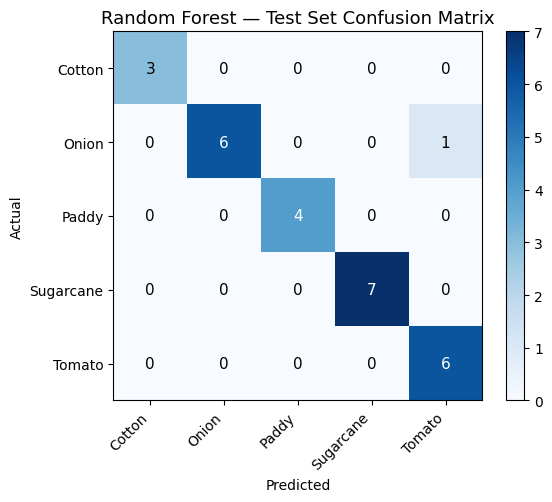

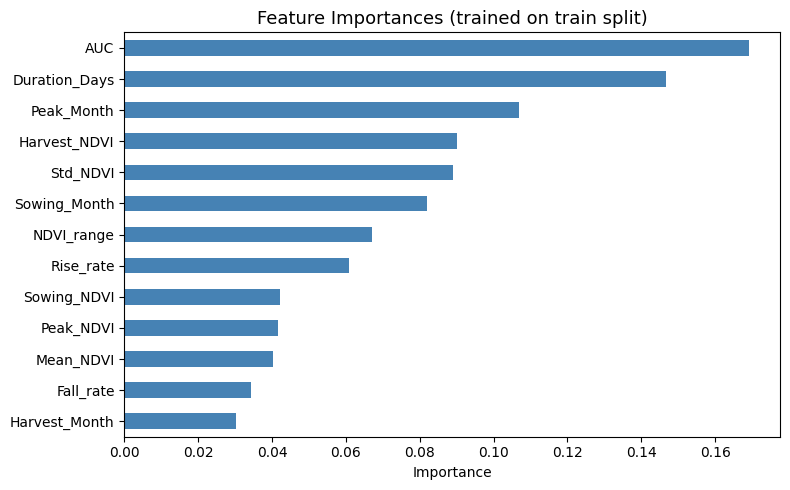

In [ ]:
n_crops = features_df['Crop'].nunique()
print(f'Classifying {n_crops} crops: {sorted(features_df["Crop"].unique())}')

FEATURE_COLS = [
    'Duration_Days', 'Peak_NDVI', 'Peak_Month',
    'Sowing_NDVI',   'Sowing_Month',
    'Harvest_NDVI',  'Harvest_Month',
    'AUC', 'Mean_NDVI', 'Std_NDVI', 'NDVI_range',
    'Rise_rate', 'Fall_rate',
]

ml_df = features_df.dropna(subset=FEATURE_COLS + ['Crop']).reset_index(drop=True)
print(f'Total valid samples: {len(ml_df)}')
print(ml_df.groupby('Crop').size().rename('n_samples'))


farm_crop = ml_df[['Farm', 'Crop']].drop_duplicates().reset_index(drop=True)
farms_arr = farm_crop['Farm'].values
crops_arr = farm_crop['Crop'].values


sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(sss1.split(farms_arr, crops_arr))

farms_train_val = farms_arr[train_val_idx]
crops_train_val = crops_arr[train_val_idx]
farms_test      = farms_arr[test_idx]


sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.176, random_state=42)
train_idx2, val_idx2 = next(sss2.split(farms_train_val, crops_train_val))

farms_train = set(farms_train_val[train_idx2])
farms_val   = set(farms_train_val[val_idx2])
farms_test  = set(farms_test)

def assign_split(farm):
    if farm in farms_train: return 'train'
    if farm in farms_val:   return 'val'
    return 'test'

ml_df['split'] = ml_df['Farm'].apply(assign_split)

train_df   = ml_df[ml_df['split'] == 'train'].reset_index(drop=True)
val_df_ml  = ml_df[ml_df['split'] == 'val'].reset_index(drop=True)
test_df_ml = ml_df[ml_df['split'] == 'test'].reset_index(drop=True)

print(f'\n── Farm-level split (no data leakage) ──')
print(f'  Train : {len(train_df)} samples  ({train_df["Crop"].nunique()} crops, {len(farms_train)} farms)')
print(f'  Val   : {len(val_df_ml)} samples  ({val_df_ml["Crop"].nunique()} crops, {len(farms_val)} farms)')
print(f'  Test  : {len(test_df_ml)} samples  ({test_df_ml["Crop"].nunique()} crops, {len(farms_test)} farms)')


farm_splits = {}
for _, row in ml_df.iterrows():
    farm_splits.setdefault(row['Farm'], set()).add(row['split'])
leaked = {f: ss for f, ss in farm_splits.items() if len(ss) > 1}
print(f'  Leaky farms: {len(leaked)}  ← should be 0')


train_df.to_excel('split_train.xlsx', index=False)
val_df_ml.to_excel('split_val.xlsx',  index=False)
test_df_ml.to_excel('split_test.xlsx', index=False)
print('\nSaved: split_train.xlsx  |  split_val.xlsx  |  split_test.xlsx')


X_train = train_df[FEATURE_COLS].values
y_train = train_df['Crop'].values

X_val   = val_df_ml[FEATURE_COLS].values
y_val   = val_df_ml['Crop'].values

X_test  = test_df_ml[FEATURE_COLS].values
y_test  = test_df_ml['Crop'].values

clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)


y_val_pred = clf.predict(X_val)
print('\n──  Validation Report  ──')
print(classification_report(y_val, y_val_pred, zero_division=0))


y_test_pred = clf.predict(X_test)
print('\n──  Test Report  (final — touch only once)  ──')
print(classification_report(y_test, y_test_pred, zero_division=0))


labels = sorted(set(y_test) | set(y_test_pred))
cm = confusion_matrix(y_test, y_test_pred, labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Random Forest — Test Set Confusion Matrix', fontsize=13)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=11)
plt.tight_layout()
plt.show()


importances = pd.Series(clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importances (trained on train split)', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 13. Export All Outputs

In [ ]:
from google.colab import files
import zipfile, os

output_files = [
    'lifecycle_results.xlsx',
    'lifecycle_results_validated.xlsx',
    'lifecycle_results_with_flags.xlsx',
    'lifecycle_features.xlsx',
    'split_train.xlsx',
    'split_val.xlsx',
    'split_test.xlsx',
]

zip_name = 'crop_lifecycle_outputs.zip'
with zipfile.ZipFile(zip_name, 'w') as zf:
    for f in output_files:
        if os.path.exists(f):
            zf.write(f)
        else:
            print(f'  (skipped — not found): {f}')

files.download(zip_name)
print('Done — downloaded', zip_name)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done — downloaded crop_lifecycle_outputs.zip


In [ ]:
import joblib

joblib.dump({
    'model': clf,
    'feature_cols': FEATURE_COLS,
}, 'crop_classifier.pkl')

print('Saved crop_classifier.pkl')

Saved crop_classifier.pkl


In [ ]:
# pip install earthengine-api
import ee

ee.Authenticate()                          # one-time browser login
ee.Initialize(project='rag-project-495705')  # your GCP project with EE enabled

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import pandas as pd

def get_ndvi_timeseries(lat, lon, start_date, end_date, cloud_thresh=40):
    point = ee.Geometry.Point([lon, lat])

    def mask_and_ndvi(img):
        scl = img.select('SCL')
        # keep clear veg/soil/water, drop cloud/shadow/cirrus classes
        mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(11))
        ndvi = img.normalizedDifference(['B8', 'B4']).rename('NDVI')
        return img.addBands(ndvi).updateMask(mask)

    coll = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(point)
            .filterDate(start_date, end_date)
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_thresh))
            .map(mask_and_ndvi))

    def extract(img):
        val = img.select('NDVI').reduceRegion(ee.Reducer.mean(), point, 10).get('NDVI')
        return ee.Feature(None, {'date': img.date().format('YYYY-MM-dd'), 'NDVI': val})

    feats = coll.map(extract).filter(ee.Filter.notNull(['NDVI']))
    data = feats.reduceColumns(ee.Reducer.toList(2), ['date', 'NDVI']).get('list').getInfo()

    df = pd.DataFrame(data, columns=['Date', 'NDVI'])
    df['Date'] = pd.to_datetime(df['Date'])
    return df.sort_values('Date').drop_duplicates(subset='Date').reset_index(drop=True)

In [ ]:
import numpy as np
from scipy.signal import find_peaks



GENERIC_CFG = {'smooth': 3, 'max_cycles': 1, 'search_months': 4, 'use_prominence': False, 'prominence': None}

def build_features_from_cycle(dates, ndvi, c):
    sow_i, peak_i, harv_i = c['sowing'], c['peak'], c['harvest']
    sow_date, peak_date, harv_date = dates[sow_i], dates[peak_i], dates[harv_i]

    seg = ndvi[sow_i:harv_i + 1]
    if len(seg) < 3:
        return None
    seg_days = (dates[sow_i:harv_i + 1] - dates[sow_i]).astype('timedelta64[D]').astype(float)

    duration  = (pd.Timestamp(harv_date) - pd.Timestamp(sow_date)).days
    rise_days = max((pd.Timestamp(peak_date) - pd.Timestamp(sow_date)).days, 1)
    fall_days = max((pd.Timestamp(harv_date) - pd.Timestamp(peak_date)).days, 1)

    feats = {
        'Duration_Days': duration,
        'Peak_NDVI':     float(ndvi[peak_i]),
        'Peak_Month':    pd.Timestamp(peak_date).month,
        'Sowing_NDVI':   float(ndvi[sow_i]),
        'Sowing_Month':  pd.Timestamp(sow_date).month,
        'Harvest_NDVI':  float(ndvi[harv_i]),
        'Harvest_Month': pd.Timestamp(harv_date).month,
        'AUC':           float(np.trapezoid(seg, x=seg_days)) if len(seg) > 1 else 0.0,
        'Mean_NDVI':     float(np.mean(seg)),
        'Std_NDVI':      float(np.std(seg)),
        'NDVI_range':    float(np.ptp(seg)),
        'Rise_rate':     round((ndvi[peak_i] - ndvi[sow_i]) / rise_days, 5),
        'Fall_rate':     round((ndvi[peak_i] - ndvi[harv_i]) / fall_days, 5),
    }
    return feats, sow_date, peak_date, harv_date

In [ ]:
model_bundle = joblib.load('crop_classifier.pkl')
clf = model_bundle['model']
FEATURE_COLS = model_bundle['feature_cols']

def predict_crop(lat, lon, ref_date, window_months=8, ground_truth=None):
    ref_date = pd.Timestamp(ref_date)
    start_date = (ref_date - pd.DateOffset(months=window_months)).strftime('%Y-%m-%d')
    end_date   = (ref_date + pd.DateOffset(months=window_months)).strftime('%Y-%m-%d')

    ndvi_df = get_ndvi_timeseries(lat, lon, start_date, end_date)
    if len(ndvi_df) < 5:
        return {'error': 'Not enough clean NDVI observations in this window'}

    dates = pd.to_datetime(ndvi_df['Date'].values).values.astype('datetime64[ns]')
    ndvi  = ndvi_df['NDVI'].values

    cycles, smoothed = detect_cycles(dates, ndvi, GENERIC_CFG)
    if len(cycles) == 0:
        return {'error': 'No lifecycle detected around this date'}

    # pick the cycle whose sowing→harvest span actually contains ref_date
    contains_ref = [c for c in cycles
                    if pd.Timestamp(dates[c['sowing']]) <= ref_date <= pd.Timestamp(dates[c['harvest']])]

    if contains_ref:
        best = contains_ref[0]
    else:
        # fallback: cycle whose peak is closest to ref_date
        best = min(cycles, key=lambda c: abs((pd.Timestamp(dates[c['peak']]) - ref_date).days))

    feats_result = build_features_from_cycle(dates, ndvi, best)
    if feats_result is None:
        return {'error': 'Cycle too short to extract features'}

    feats, sow_date, peak_date, harv_date = feats_result
    X = pd.DataFrame([feats])[FEATURE_COLS].values

    probs = clf.predict_proba(X)[0]
    order = np.argsort(probs)[::-1]

    output = {
        'lat': lat, 'lon': lon, 'ref_date': str(ref_date.date()),
        'predicted_crop': clf.classes_[order[0]],
        'confidence_pct': round(float(probs[order[0]]) * 100, 2),
        'top3': [(clf.classes_[i], round(float(probs[i]) * 100, 2)) for i in order[:3]],
        'sowing_date': str(pd.Timestamp(sow_date).date()),
        'peak_date': str(pd.Timestamp(peak_date).date()),
        'harvest_date': str(pd.Timestamp(harv_date).date()),
        'ref_date_inside_detected_cycle': bool(contains_ref),
    }
    if ground_truth is not None:
        output['ground_truth'] = ground_truth
        output['correct'] = output['predicted_crop'] == ground_truth
    return output

In [ ]:
res = predict_crop(lat=13.569278, lon=78.455592, ref_date='2023-10-6')
print(res)